In [1]:
# Clear module cache to ensure fresh imports
import sys

# Remove cached modules related to src
modules_to_remove = [key for key in sys.modules.keys() if 'src' in key]
for module in modules_to_remove:
    del sys.modules[module]

In [2]:
from pathlib import Path
import sys
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set working directory to project root
notebook_dir = Path.cwd()
project_root = notebook_dir

# Walk up to find project root with 'src' directory
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

# Change to project root
os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")
print(f"src path exists: {(project_root / 'src').exists()}")

from src.data_pipeline import (
    SAMPLE_UNIVERSE,
    DataPreprocessor,
    YahooFinanceProvider,
)

from src.covariance import (
    compute_covariance_matrix,
    compute_correlation_matrix,
    validate_covariance_matrix,
    validate_correlation_matrix,
    rank_correlations,
    compute_average_correlation,
    compute_distance_matrix,
)

Project root: D:\PGDBA\MyNotes\SEM-3\Part-1\FRM\Project\adaptive-portfolio-risk-analytics
src path exists: True


In [3]:
symbols = list(SAMPLE_UNIVERSE)

provider = YahooFinanceProvider()

market_data = provider.get_market_data(
    symbols,
    "2020-01-01",
    "2024-12-31",
)

prices_df = DataPreprocessor.handle_missing_values(
    market_data.prices_df
)

stage_2_outputs = (
    DataPreprocessor.build_returns_risk_outputs(
        prices_df
    )
)

log_returns_df = stage_2_outputs.log_returns_df

In [4]:
covariance_matrix_df = compute_covariance_matrix(
    log_returns_df
)

correlation_matrix_df = compute_correlation_matrix(
    log_returns_df
)

print(
    "Covariance Matrix Valid:",
    validate_covariance_matrix(
        covariance_matrix_df
    )
)

print(
    "Correlation Matrix Valid:",
    validate_correlation_matrix(
        correlation_matrix_df
    )
)

Covariance Matrix Valid: True
Correlation Matrix Valid: True


In [5]:
display(covariance_matrix_df)

display(correlation_matrix_df)

asset,GOLDBEES.NS,HDFCBANK.NS,TCS.NS
asset,,,
GOLDBEES.NS,0.000078,-0.000006,0.000008
HDFCBANK.NS,-0.000006,0.000297,0.000084
TCS.NS,0.000008,0.000084,0.000238


asset,GOLDBEES.NS,HDFCBANK.NS,TCS.NS
asset,,,
GOLDBEES.NS,1.000000,-0.036736,0.060586
HDFCBANK.NS,-0.036736,1.000000,0.317594
TCS.NS,0.060586,0.317594,1.000000


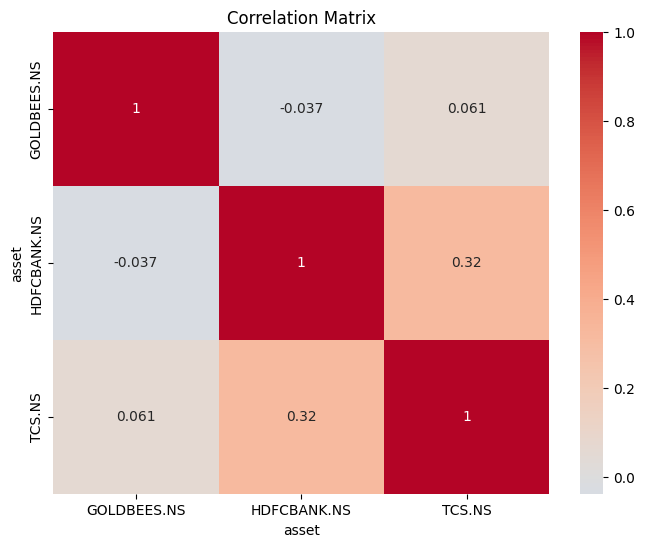

In [6]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix_df,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [7]:
distance_matrix_df = compute_distance_matrix(
    correlation_matrix_df
)

display(distance_matrix_df)

asset,GOLDBEES.NS,HDFCBANK.NS,TCS.NS
asset,,,
GOLDBEES.NS,0.000000,0.719978,0.685352
HDFCBANK.NS,0.719978,0.000000,0.584126
TCS.NS,0.685352,0.584126,0.000000


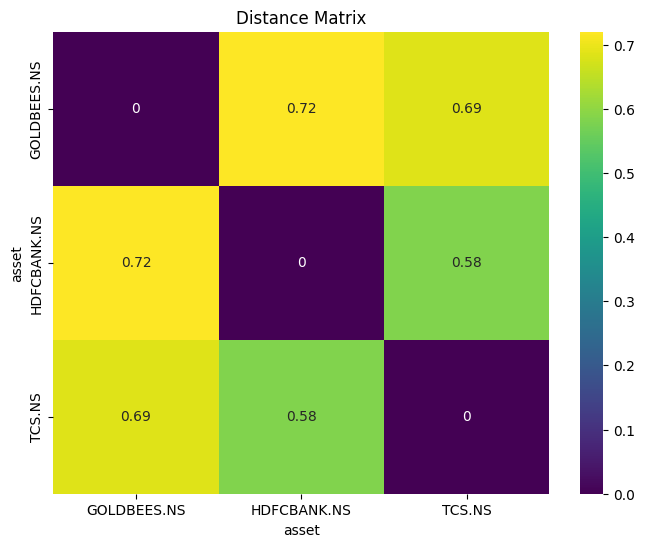

In [8]:
plt.figure(figsize=(8,6))

sns.heatmap(
    distance_matrix_df,
    annot=True,
    cmap="viridis"
)

plt.title("Distance Matrix")
plt.show()

In [9]:
correlation_rankings_df = rank_correlations(
    correlation_matrix_df
)
display(correlation_rankings_df)


,Asset A,Asset B,Correlation
0,HDFCBANK.NS,TCS.NS,0.317594
1,GOLDBEES.NS,TCS.NS,0.060586
2,GOLDBEES.NS,HDFCBANK.NS,-0.036736


In [10]:
average_correlation = compute_average_correlation(
    correlation_matrix_df
)

print(f"Average Correlation: {average_correlation:.4f}")


Average Correlation: 0.1138
